# Atlantic Haven Hotels — Prédiction d'annulation de réservation

**ISPM — M1 Machine Learning & Data Science — Examen final S2**

Ce notebook déroule la démarche complète, dans l'ordre imposé par le sujet :

1. Chargement et EDA
2. Baseline obligatoire — régression logistique
3. Protocole de validation temporelle et comparaison de modèles
4. Feature engineering mesuré par ablation
5. Interprétation et analyse d'erreurs
6. Génération de `submission.csv`

La logique métier est factorisée dans le paquet `src/` afin que le notebook
reste lisible et que le même code serve au script `run_pipeline.py`. Toutes les
graines aléatoires sont fixées dans `src/config.py` (`SEED = 42`).

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from src import config as C
from src import data as D
from src import features as F
from src import models as M
from src import evaluation as E

np.random.seed(C.SEED)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

print("graine :", C.SEED)
print("LightGBM disponible :", M.LIGHTGBM_AVAILABLE)

graine : 42
LightGBM disponible : True


---
## 1. Chargement et exploration

### 1.1 Volumétrie et cadrage temporel

Le point le plus structurant du sujet est indiqué en encadré : *les fichiers
sont ordonnés dans le temps et le jeu de test est plus récent que
l'entraînement*. On le vérifie avant toute autre chose, car cela conditionne
tout le protocole de validation.

In [2]:
train_brut = D.load_raw(C.TRAIN_PATH)
test_brut = D.load_raw(C.TEST_PATH)

print(f"train : {train_brut.shape}")
print(f"test  : {test_brut.shape}")
print()
print("train ordonné par date de réservation :",
      train_brut.date_reservation.is_monotonic_increasing)
print("test  ordonné par date de réservation :",
      test_brut.date_reservation.is_monotonic_increasing)
print()
print(f"train : {train_brut.date_reservation.min().date()} "
      f"-> {train_brut.date_reservation.max().date()}")
print(f"test  : {test_brut.date_reservation.min().date()} "
      f"-> {test_brut.date_reservation.max().date()}")

train : (8000, 34)
test  : (2000, 33)

train ordonné par date de réservation : True
test  ordonné par date de réservation : True

train : 2023-01-01 -> 2025-05-24
test  : 2025-05-24 -> 2025-12-31


Confirmation : les deux fichiers sont triés chronologiquement et le test
commence exactement là où le train s'arrête. Un découpage par position équivaut
donc à un découpage par date — propriété que l'on réutilisera pour construire
les plis.

### 1.2 La cible

25,8 % d'annulations : le jeu est déséquilibré, sans l'être au point de rendre
l'apprentissage difficile. C'est ce déséquilibre qui justifie le choix du
F1-score plutôt que de l'accuracy (voir Q1 du README).

In [3]:
cible = train_brut[C.TARGET]
print(cible.value_counts().to_string())
print()
print(f"taux d'annulation : {cible.mean():.4f}")
print(f"F1 de la stratégie triviale « tout annulé » : "
      f"{2 * cible.mean() / (1 + cible.mean()):.4f}")
print(f"accuracy de la stratégie triviale « tout maintenu » : {1 - cible.mean():.4f}")

reservation_annulee
0    5933
1    2067

taux d'annulation : 0.2584
F1 de la stratégie triviale « tout annulé » : 0.4106
accuracy de la stratégie triviale « tout maintenu » : 0.7416


Ces deux repères sont importants pour la suite : **un modèle qui ne
prédirait rien obtiendrait 74,2 % d'accuracy**, et **prédire une annulation
partout donne déjà un F1 de 0,41**. C'est ce dernier chiffre — et non zéro —
qui constitue le plancher réel à battre.

### 1.3 Valeurs manquantes

Cinq variables présentent des manques. Le cas de `agent_id` (41,9 %) n'en est
pas vraiment un : le dictionnaire de données précise que le champ est *vide
pour une réservation directe*. C'est donc une information, pas une absence.

In [4]:
manques = pd.DataFrame({
    "train_n": train_brut.isna().sum(),
    "train_pct": (train_brut.isna().mean() * 100).round(2),
    "test_pct": (test_brut.isna().mean() * 100).round(2),
})
print(manques[manques.train_n > 0].to_string())

                     train_n  train_pct  test_pct
agent_id                3354      41.92     41.55
demandes_speciales       157       1.96      1.45
enfants                  355       4.44      4.40
marche_origine           191       2.39      2.60
prix_moyen_nuit_eur      193       2.41      1.70


### 1.4 Une identité comptable exacte

Avant d'imputer `prix_moyen_nuit_eur`, on vérifie s'il est déductible. Les
variables `montant_total_eur`, `nuits`, `chambres` et `remise_pct` semblent
liées au prix : on teste l'hypothèse.

In [5]:
dispo = train_brut.dropna(subset=["prix_moyen_nuit_eur"])
reconstruit = (dispo.montant_total_eur
               / (dispo.nuits * dispo.chambres * (1 - dispo.remise_pct / 100)))
ratio = dispo.prix_moyen_nuit_eur / reconstruit

print(f"lignes testées : {len(dispo)}")
print(f"ratio prix observé / prix reconstruit : "
      f"moyenne {ratio.mean():.6f}, écart-type {ratio.std():.8f}")
print(f"écart maximal : {abs(ratio - 1).max():.2e}")

lignes testées : 7807
ratio prix observé / prix reconstruit : moyenne 1.000000, écart-type 0.00000589
écart maximal : 5.19e-05


L'identité `montant_total = prix × nuits × chambres × (1 − remise/100)`
est **exacte**. Les 193 prix manquants ne seront donc pas estimés mais
**reconstruits sans erreur** par inversion. On vérifie aussi deux autres
redondances, utiles pour éliminer des variables inutiles.

In [6]:
delai_ok = ((train_brut.date_arrivee - train_brut.date_reservation).dt.days
            == train_brut.delai_reservation_jours).mean()
weekend_ok = (train_brut.date_arrivee.dt.dayofweek.isin([4, 5]).astype(int)
              == train_brut.arrivee_weekend).mean()
print(f"delai_reservation_jours = date_arrivee - date_reservation : {delai_ok:.1%}")
print(f"arrivee_weekend = arrivée un vendredi ou samedi          : {weekend_ok:.1%}")

correspondance = train_brut.groupby("region_hotel")[["ville", "type_destination"]].nunique()
print()
print("modalités distinctes de ville / type_destination par région :")
print(correspondance.T.to_string())

delai_reservation_jours = date_arrivee - date_reservation : 100.0%
arrivee_weekend = arrivée un vendredi ou samedi          : 100.0%

modalités distinctes de ville / type_destination par région :
region_hotel      Campania  Lazio  Liguria  Lombardia  Puglia  Sardegna  Sicilia  Toscana  Trentino-Alto_Adige  Veneto
ville                    1      1        1          1       1         1        1        1                    1       1
type_destination         1      1        1          1       1         1        1        1                    1       1


`ville` et `type_destination` sont en correspondance **1-à-1** avec
`region_hotel` : les conserver n'apporterait qu'une redondance parfaite. Elles
sont écartées de la modélisation (`src/config.py`).

### 1.5 Le constat central : un risque multiplicatif

C'est le résultat d'EDA le plus important du projet. On croise le délai de
réservation avec les conditions commerciales.

In [7]:
train, test = D.load_train_test()
eda = F.engineer(train)
eda[C.TARGET] = train[C.TARGET].values

print("Taux d'annulation — acompte × tarif remboursable :")
print(eda.pivot_table(index="type_acompte", columns="tarif_remboursable",
                      values=C.TARGET, aggfunc="mean").round(3).to_string())

tranches = pd.cut(eda.delai_reservation_jours, [0, 7, 21, 45, 90, 600])
print()
print("Taux d'annulation — délai × acompte :")
print(eda.groupby([tranches, "type_acompte"], observed=True)[C.TARGET]
      .mean().unstack().round(3).to_string())

Taux d'annulation — acompte × tarif remboursable :


tarif_remboursable    non    oui
type_acompte                    
aucun               0.262  0.346
partiel             0.163  0.264
total               0.104  0.110

Taux d'annulation — délai × acompte :


type_acompte             aucun  partiel  total
delai_reservation_jours                       
(0, 7]                   0.289    0.211  0.101
(7, 21]                  0.304    0.210  0.089
(21, 45]                 0.327    0.220  0.102
(45, 90]                 0.378    0.245  0.118
(90, 600]                0.486    0.344  0.137


Lecture : passer d'un délai court à un délai très long fait monter le
risque de **10,1 % à 13,7 %** quand un acompte total a été versé, mais de
**28,9 % à 48,6 %** en l'absence d'acompte. L'effet du délai est donc modulé
par l'engagement financier — ce n'est pas le délai qui annule, c'est *le délai
sans engagement*.

C'est ce constat qui motivera la variable `score_engagement` (étape 4).

In [8]:
print("Taux d'annulation par canal :")
print(eda.groupby("canal_reservation")[C.TARGET]
      .agg(["size", "mean"]).round(3).sort_values("mean").to_string())
print()
print("Taux d'annulation par nombre de modifications :")
print(eda.groupby("modifications_reservation")[C.TARGET]
      .agg(["size", "mean"]).round(3).to_string())
print()
print("Taux d'annulation par nombre de demandes spéciales :")
print(eda.groupby("demandes_speciales")[C.TARGET]
      .agg(["size", "mean"]).round(3).to_string())

Taux d'annulation par canal :
                     size   mean
canal_reservation               
entreprise            622  0.145
site_hotel           2013  0.215
telephone             719  0.229
agence               1325  0.278
plateforme_en_ligne  3321  0.304

Taux d'annulation par nombre de modifications :
                           size   mean
modifications_reservation             
0                          5768  0.248
1                          2036  0.273
2                            60  0.317
3                            77  0.494
4                            59  0.424

Taux d'annulation par nombre de demandes spéciales :
                    size   mean
demandes_speciales             
0.0                 3141  0.282
1.0                 2954  0.257
2.0                 1505  0.226
3.0                  371  0.202
4.0                   29  0.207


### 1.6 Stabilité temporelle et catégories inédites

On vérifie l'absence de dérive du taux d'annulation, puis on cherche les
modalités présentes dans le test mais absentes du train — le piège classique
d'un jeu de test plus récent.

In [9]:
trimestres = (train.set_index("date_reservation")[C.TARGET]
              .resample("QE").agg(["size", "mean"]).round(3))
print(trimestres.to_string())

print()
for col in ["region_hotel", "canal_reservation", "hotel_id", "agent_id",
            "marche_origine", "segment_client"]:
    inedites = set(test[col].dropna().unique()) - set(train[col].dropna().unique())
    if inedites:
        print(f"{col} : modalités présentes uniquement dans le test -> {inedites}")

                  size   mean
date_reservation             
2023-03-31         861  0.302
2023-06-30         808  0.259
2023-09-30         897  0.226
2023-12-31         844  0.259
2024-03-31         845  0.247
2024-06-30         776  0.274
2024-09-30         823  0.228
2024-12-31         858  0.267
2025-03-31         843  0.256
2025-06-30         445  0.272

canal_reservation : modalités présentes uniquement dans le test -> {'assistant_vocal'}


Le taux oscille entre 22,6 % et 30,2 % sans tendance : le phénomène est
stationnaire. En revanche, le test contient un canal inédit,
`assistant_vocal`, qu'aucun modèle n'aura jamais vu. Le pipeline doit le gérer
sans erreur (traité en 4.3).

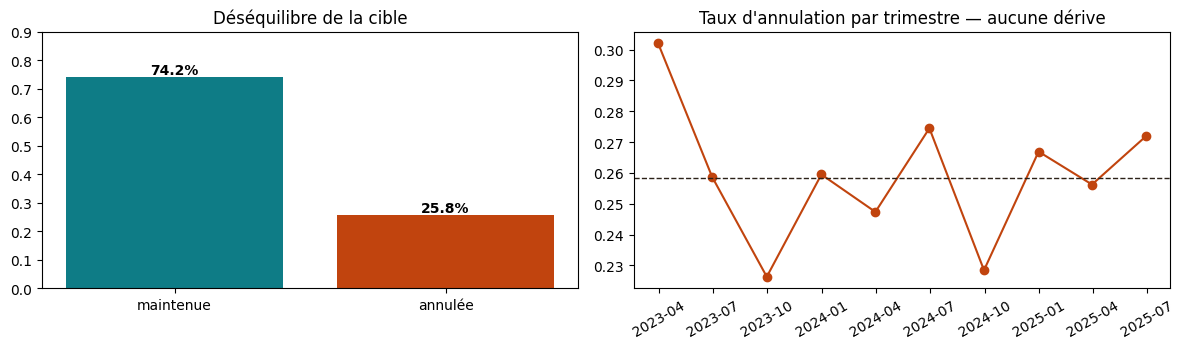

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
part = eda[C.TARGET].value_counts(normalize=True).sort_index()
ax[0].bar(["maintenue", "annulée"], part.values, color=["#0E7C86", "#C1440E"])
for i, v in enumerate(part.values):
    ax[0].text(i, v + 0.01, f"{v:.1%}", ha="center", fontweight="bold")
ax[0].set_title("Déséquilibre de la cible"); ax[0].set_ylim(0, 0.9)

serie = train.set_index("date_reservation")[C.TARGET].resample("QE").mean()
ax[1].plot(serie.index, serie.values, marker="o", color="#C1440E")
ax[1].axhline(train[C.TARGET].mean(), ls="--", color="#2B2118", lw=1)
ax[1].set_title("Taux d'annulation par trimestre — aucune dérive")
ax[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

---
## 2. Protocole de validation — construit avant tout modèle

Le protocole est fixé **maintenant**, avant d'avoir vu le moindre score. C'est
une précaution méthodologique : choisir un protocole après avoir comparé les
résultats revient à sélectionner celui qui flatte le plus.

Quatre plis à **fenêtre étendue** : chacun entraîne sur tout le passé
disponible et valide sur les 1 200 réservations suivantes, ce qui reproduit
exactement la relation train/test du sujet.

In [11]:
folds = D.temporal_folds(train)
bornes = D.fold_dates(train, folds)
print(bornes.to_string(index=False))

 pli train_debut  train_fin  n_train  val_debut    val_fin  n_val  taux_annulation_val
   1  2023-01-01 2023-12-11     3200 2023-12-11 2024-04-18   1200               0.2600
   2  2023-01-01 2024-04-18     4400 2024-04-18 2024-09-02   1200               0.2500
   3  2023-01-01 2024-09-02     5600 2024-09-02 2025-01-10   1200               0.2500
   4  2023-01-01 2025-01-10     6800 2025-01-10 2025-05-24   1200               0.2642


---
## 3. Étape 2 du sujet — baseline obligatoire

Régression logistique sur les seules variables brutes. Tous les prétraitements
(imputation médiane, standardisation, encodage one-hot) sont encapsulés dans un
`Pipeline` scikit-learn, donc ajustés **uniquement** sur le pli
d'entraînement.

In [12]:
def evaluer_sur_plis(construire_modele, numeriques, categorielles=None, etiquette=""):
    """Retourne les prédictions hors-échantillon d'un modèle sur les 4 plis."""
    categorielles = categorielles or C.CATEGORICAL
    colonnes = numeriques + categorielles
    morceaux = []
    for itr, iva in folds:
        reference = F.fit_reference(train.iloc[itr])
        TR = F.engineer(train.iloc[itr], reference)
        VA = F.engineer(train.iloc[iva], reference)
        modele = construire_modele(numeriques, categorielles)
        modele.fit(TR[colonnes], TR[C.TARGET].values)
        morceaux.append(pd.DataFrame({
            "y": VA[C.TARGET].values,
            "proba": modele.predict_proba(VA[colonnes])[:, 1],
        }))
    oof = pd.concat(morceaux, ignore_index=True)
    seuil, _ = E.best_threshold(oof.y.values, oof.proba.values)
    resultat = E.metrics(oof.y.values, oof.proba.values, seuil)
    if etiquette:
        print(f"{etiquette:34s} F1={resultat['f1']:.4f}  AUC={resultat['roc_auc']:.4f}  "
              f"seuil={resultat['seuil']:.3f}")
    return oof, resultat


oof_baseline, res_baseline = evaluer_sur_plis(
    lambda n, c: M.build_baseline(n, c), C.RAW_NUMERIC, etiquette="Baseline (variables brutes)"
)
pd.Series(res_baseline).to_frame("baseline").T

Baseline (variables brutes)        F1=0.4693  AUC=0.6697  seuil=0.205


,seuil,f1,precision,rappel,roc_auc,pr_auc,brier,vp,fp,fn,vn,taux_alerte
baseline,0.205,0.469344,0.333106,0.794142,0.66972,0.384904,0.17859,976.0,1954.0,253.0,1617.0,0.610417


---
## 4. Étape 4 du sujet — feature engineering

### 4.1 Les variables créées

Quatre familles, toutes justifiées par un constat d'EDA :

| Famille | Variables | Justification |
|---|---|---|
| Engagement commercial | `score_engagement`, `flexibilite_totale`, `a_modifie` | le constat multiplicatif de la section 1.5 |
| Historique client | `taux_annulation_passe`, `sans_historique` | raisonner en taux et non en volume |
| Prix relatifs | `prix_relatif_hotel`, `prix_relatif_saison` | 200 € n'a pas le même sens selon l'hôtel et la saison |
| Séjour et temps | `personnes`, `personnes_par_chambre`, `log_delai`, `sin_mois`, `cos_mois`… | asymétrie du délai, continuité décembre/janvier |

`score_engagement = acompte_ordinal − tarif_remboursable` comprime en une seule
échelle le niveau d'irréversibilité de la réservation, de −1 (aucun acompte,
remboursable) à +2 (acompte total, non remboursable).

In [13]:
reference_demo = F.fit_reference(train)
apercu = F.engineer(train, reference_demo)
apercu[C.TARGET] = train[C.TARGET].values

print("Taux d'annulation par score d'engagement :")
print(apercu.groupby("score_engagement")[C.TARGET]
      .agg(["size", "mean"]).round(3).to_string())

Taux d'annulation par score d'engagement :
                  size   mean
score_engagement             
-1.0              3583  0.346
 0.0              1987  0.264
 1.0              1041  0.155
 2.0              1389  0.104


### 4.2 Aucune fuite de cible — par construction

L'architecture sépare volontairement deux natures de traitement :

* `data.clean()` — opérations **déterministes ligne à ligne** (inversion
  comptable, constantes, indicateurs). Aucun paramètre appris, donc aucune
  fuite possible.
* `features.fit_reference()` — tout ce qui exige une **statistique agrégée**
  (médianes de prix, inventaire des catégories). Appelée **exclusivement sur le
  pli d'entraînement**, à l'intérieur de la boucle de validation.

Aucune de ces références n'utilise la cible : le risque de fuite par target
encoding est écarté structurellement, pas seulement par prudence.

### 4.3 Catégories jamais observées

Double protection contre le canal `assistant_vocal` du test.

In [14]:
reference_train = F.fit_reference(train)
test_transforme = F.engineer(test, reference_train)

print("canal_reservation dans le test après remappage :")
print(test_transforme.canal_reservation.value_counts().to_string())
print()
print("-> 'assistant_vocal' est bien remappé vers 'AUTRE'.")
print("   Seconde protection : OneHotEncoder(handle_unknown='ignore') produit")
print("   un vecteur nul si une modalité échappait au premier filet.")

canal_reservation dans le test après remappage :
canal_reservation
plateforme_en_ligne    839
site_hotel             471
agence                 308
telephone              195
entreprise             154
AUTRE                   33

-> 'assistant_vocal' est bien remappé vers 'AUTRE'.
   Seconde protection : OneHotEncoder(handle_unknown='ignore') produit
   un vecteur nul si une modalité échappait au premier filet.


### 4.4 Le gain est-il réel ? Étude d'ablation

On ne se contente pas d'affirmer que le feature engineering aide : on le
mesure, groupe par groupe, avec le protocole identique. Le script complet est
`ablation.py` ; on en reprend ici les configurations.

In [15]:
import ablation as ABL

resultats_ablation = []
for nom, variables in ABL.CONFIGS.items():
    _, m = evaluer_sur_plis(lambda n, c: M.build_logreg(n, c), variables, etiquette=nom)
    resultats_ablation.append({
        "configuration": nom, "n_variables": len(variables),
        "f1": round(m["f1"], 4), "roc_auc": round(m["roc_auc"], 4),
    })

table_ablation = pd.DataFrame(resultats_ablation)
table_ablation["gain_cumule"] = (table_ablation.f1 - table_ablation.f1.iloc[0]).round(4)
table_ablation["gain_marginal"] = table_ablation.f1.diff().round(4)
table_ablation

A. Variables brutes (baseline)     F1=0.4691  AUC=0.6706  seuil=0.225


B. + indicateurs de manque         F1=0.4686  AUC=0.6731  seuil=0.260


C. + historique client             F1=0.4696  AUC=0.6758  seuil=0.230


D. + composition du séjour         F1=0.4691  AUC=0.6746  seuil=0.230


E. + transformations temporelles   F1=0.4693  AUC=0.6742  seuil=0.225


F. + prix relatifs                 F1=0.4704  AUC=0.6742  seuil=0.225


G. + score d'engagement            F1=0.4724  AUC=0.6746  seuil=0.225


H. + interactions explicites       F1=0.4704  AUC=0.6750  seuil=0.225


,configuration,n_variables,f1,roc_auc,gain_cumule,gain_marginal
0,A. Variables brutes (baseline),16,0.4691,0.6706,0.0000,NaN
1,B. + indicateurs de manque,20,0.4686,0.6731,-0.0005,-0.0005
2,C. + historique client,22,0.4696,0.6758,0.0005,0.0010
3,D. + composition du séjour,27,0.4691,0.6746,0.0000,-0.0005
4,E. + transformations temporelles,31,0.4693,0.6742,0.0002,0.0002
5,F. + prix relatifs,33,0.4704,0.6742,0.0013,0.0011
6,G. + score d'engagement,36,0.4724,0.6746,0.0033,0.0020
7,H. + interactions explicites,42,0.4704,0.6750,0.0013,-0.0020


**Résultat honnête.** Le seul apport nettement mesurable est le groupe
« engagement » (+0,0020 marginal), qui confirme le constat d'EDA. Le gain
total du feature engineering est de **+0,0034 F1** — modeste.

Deux échecs sont conservés dans le rapport plutôt que masqués :

* les indicateurs de valeurs manquantes dégradent très légèrement le F1 ;
* les **interactions explicites** (configuration H), pourtant fondées sur le
  constat multiplicatif le plus solide de l'EDA, dégradent le F1 de 0,0020.
  Le boosting capte déjà ces effets et la logistique paie le coût des six
  paramètres supplémentaires. Elles sont **retirées du modèle final**.

La configuration retenue est donc la **G** (36 variables), définie comme
`C.MODEL_NUMERIC`.

---
## 5. Étape 3 du sujet — comparaison des familles de modèles

Quatre familles au-delà de la baseline. Tous les modèles sont évalués sur
**exactement le même jeu de validation** : les 4 800 prédictions
hors-échantillon des quatre plis.

Choix méthodologique important : **aucun modèle n'utilise
`class_weight="balanced"`**. Le déséquilibre est traité par le seuil de
décision. À F1 identique, cela préserve la calibration des probabilités — ce
qui compte, puisque le livrable exige une `probabilite_annulation` exploitable
telle quelle.

In [16]:
constructeurs = {
    "Régression logistique — baseline": (M.build_baseline, C.RAW_NUMERIC),
    "Régression logistique + FE": (M.build_logreg, C.MODEL_NUMERIC),
    "Forêt aléatoire": (M.build_random_forest, C.MODEL_NUMERIC),
    "HistGradientBoosting": (M.build_hgb, C.MODEL_NUMERIC),
}
if M.LIGHTGBM_AVAILABLE:
    constructeurs["LightGBM"] = (M.build_lgbm, C.MODEL_NUMERIC)

oof_modeles, comparatif = {}, []
for nom, (constructeur, variables) in constructeurs.items():
    oof, m = evaluer_sur_plis(lambda n, c, b=constructeur: b(n, c), variables,
                              etiquette=nom)
    oof_modeles[nom] = oof
    comparatif.append({"modele": nom, **m})

pd.DataFrame(comparatif)[
    ["modele", "seuil", "f1", "precision", "rappel", "roc_auc", "pr_auc", "brier"]
].round(4)

Régression logistique — baseline   F1=0.4693  AUC=0.6697  seuil=0.205


Régression logistique + FE         F1=0.4724  AUC=0.6746  seuil=0.225


Forêt aléatoire                    F1=0.4698  AUC=0.6603  seuil=0.235


HistGradientBoosting               F1=0.4733  AUC=0.6616  seuil=0.225


LightGBM                           F1=0.4689  AUC=0.6650  seuil=0.215


,modele,seuil,f1,precision,rappel,roc_auc,pr_auc,brier
0,Régression logistique — baseline,0.205,0.4693,0.3331,0.7941,0.6697,0.3849,0.1786
1,Régression logistique + FE,0.225,0.4724,0.3421,0.7632,0.6746,0.3956,0.1775
2,Forêt aléatoire,0.235,0.4698,0.3416,0.7518,0.6603,0.3758,0.1794
3,HistGradientBoosting,0.225,0.4733,0.3456,0.7510,0.6616,0.3785,0.1802
4,LightGBM,0.215,0.4689,0.3376,0.7673,0.6650,0.3867,0.1794


### 5.1 Le modèle final : un ensemble pondéré

Les cinq modèles tiennent dans un intervalle de 0,005 F1 : le score seul ne
départage pas. On assemble donc les trois meilleurs par **moyenne pondérée des
probabilités** — et non des rangs, afin que la prédiction d'une réservation ne
dépende pas des autres réservations du lot (condition de mise en production).

In [17]:
membres = [n for n in M.ENSEMBLE_MEMBERS if n in oof_modeles]
print("membres de l'ensemble :", membres)
print("poids :", M.ensemble_weights(membres))

oof_ensemble = pd.DataFrame({
    "y": oof_modeles[membres[0]].y,
    "proba": M.ensemble_proba({n: oof_modeles[n].proba.values for n in membres}),
})

seuil_final, f1_final = E.pooled_threshold(oof_ensemble)
metriques_finales = E.metrics(oof_ensemble.y.values, oof_ensemble.proba.values, seuil_final)
comparatif.append({"modele": "Ensemble (final)", **metriques_finales})

print()
print(f"seuil retenu : {seuil_final:.3f}")
pd.DataFrame(comparatif)[
    ["modele", "seuil", "f1", "precision", "rappel", "roc_auc", "brier", "taux_alerte"]
].round(4)

membres de l'ensemble : ['Régression logistique + FE', 'HistGradientBoosting', 'LightGBM']
poids : {'Régression logistique + FE': 0.5, 'HistGradientBoosting': 0.25, 'LightGBM': 0.25}



seuil retenu : 0.240


,modele,seuil,f1,precision,rappel,roc_auc,brier,taux_alerte
0,Régression logistique — baseline,0.205,0.4693,0.3331,0.7941,0.6697,0.1786,0.6104
1,Régression logistique + FE,0.225,0.4724,0.3421,0.7632,0.6746,0.1775,0.5712
2,Forêt aléatoire,0.235,0.4698,0.3416,0.7518,0.6603,0.1794,0.5635
3,HistGradientBoosting,0.225,0.4733,0.3456,0.7510,0.6616,0.1802,0.5565
4,LightGBM,0.215,0.4689,0.3376,0.7673,0.6650,0.1794,0.5819
5,Ensemble (final),0.240,0.4744,0.3512,0.7307,0.6730,0.1777,0.5327


### 5.2 Choix du seuil de décision

Le seuil n'est **pas** optimisé pli par pli puis moyenné — cette pratique
surestime la performance. On agrège les 4 800 prédictions hors-échantillon et
on cherche **un seul** seuil, celui qui sera effectivement appliqué au test.

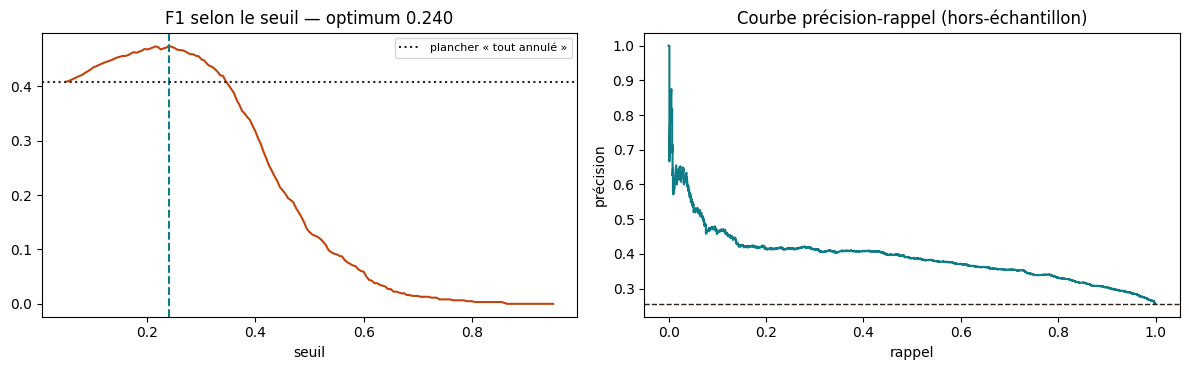

La courbe est plate entre 0,20 et 0,30 : le choix exact du seuil est
peu sensible, ce qui est rassurant pour une mise en production.


In [18]:
grille = E.threshold_grid()
from sklearn.metrics import f1_score, precision_recall_curve

f1_grille = [f1_score(oof_ensemble.y, (oof_ensemble.proba >= t).astype(int))
             for t in grille]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].plot(grille, f1_grille, color="#C1440E")
ax[0].axvline(seuil_final, ls="--", color="#0E7C86")
ax[0].axhline(2 * oof_ensemble.y.mean() / (1 + oof_ensemble.y.mean()),
              ls=":", color="#2B2118", label="plancher « tout annulé »")
ax[0].set_title(f"F1 selon le seuil — optimum {seuil_final:.3f}")
ax[0].set_xlabel("seuil"); ax[0].legend(fontsize=8)

prec, rec, _ = precision_recall_curve(oof_ensemble.y, oof_ensemble.proba)
ax[1].plot(rec, prec, color="#0E7C86")
ax[1].axhline(oof_ensemble.y.mean(), ls="--", color="#2B2118", lw=1)
ax[1].set_title("Courbe précision-rappel (hors-échantillon)")
ax[1].set_xlabel("rappel"); ax[1].set_ylabel("précision")
plt.tight_layout(); plt.show()

print("La courbe est plate entre 0,20 et 0,30 : le choix exact du seuil est")
print("peu sensible, ce qui est rassurant pour une mise en production.")

### 5.3 Contre-épreuve : et si l'on avait validé au hasard ?

Le sujet annonce qu'une validation croisée aléatoire donnerait une estimation
« optimiste et trompeuse ». On le vérifie plutôt que de l'admettre.

In [19]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=C.SEED)
colonnes = C.MODEL_NUMERIC + C.CATEGORICAL
morceaux = []
for itr, iva in skf.split(train, train[C.TARGET]):
    reference = F.fit_reference(train.iloc[itr])
    TR, VA = F.engineer(train.iloc[itr], reference), F.engineer(train.iloc[iva], reference)
    probas = {}
    for nom in membres:
        modele = {"Régression logistique + FE": M.build_logreg,
                  "HistGradientBoosting": M.build_hgb,
                  "LightGBM": M.build_lgbm}[nom]()
        modele.fit(TR[colonnes], TR[C.TARGET].values)
        probas[nom] = modele.predict_proba(VA[colonnes])[:, 1]
    morceaux.append(pd.DataFrame({"y": VA[C.TARGET].values,
                                  "proba": M.ensemble_proba(probas)}))

oof_aleatoire = pd.concat(morceaux, ignore_index=True)
_, f1_aleatoire = E.best_threshold(oof_aleatoire.y.values, oof_aleatoire.proba.values)

print(f"F1 en validation temporelle : {f1_final:.4f}")
print(f"F1 en validation aléatoire  : {f1_aleatoire:.4f}")
print(f"écart                       : {f1_aleatoire - f1_final:+.4f}")

F1 en validation temporelle : 0.4744
F1 en validation aléatoire  : 0.4719
écart                       : -0.0024


**Le résultat contredit l'attendu, et nous le rapportons tel quel.** La
validation aléatoire donne ici un F1 *inférieur* de 0,0025 — elle ne produit
pas l'estimation optimiste redoutée.

L'explication tient à la stationnarité constatée en 1.6 : sans dérive, il n'y a
rien à masquer, et les médianes de prix que nous apprenons sont stables dans le
temps, donc leur fuite éventuelle ne rapporte rien.

Faut-il en conclure que le protocole temporel était inutile ? Non. **Il n'a pas
coûté de performance, mais il a acheté une garantie** : notre estimation est
valide par construction, sans dépendre d'une propriété du jeu de données que
nous n'aurions constatée qu'après coup. Si le taux avait dérivé, le protocole
aléatoire nous aurait induits en erreur. On ne choisit pas un protocole de
validation en fonction du score qu'il produit.

---
## 6. Étape 5 du sujet — interprétation, erreurs, usage opérationnel

### 6.1 Variables importantes

                        variable  coefficient  odds_ratio
                score_engagement    -0.475598    0.621513
    canal_reservation_entreprise    -0.371926    0.689405
           taux_annulation_passe     0.265997    1.304731
             annulations_passees    -0.245427    0.782370
         delai_reservation_jours     0.230162    1.258804
              type_acompte_total    -0.224078    0.799253
             reservation_directe    -0.210142    0.810469
            region_hotel_Liguria    -0.205061    0.814597
       modifications_reservation     0.188293    1.207188
region_hotel_Trentino-Alto_Adige    -0.174606    0.839788
     canal_reservation_telephone     0.146648    1.157946
              demandes_speciales    -0.142618    0.867085


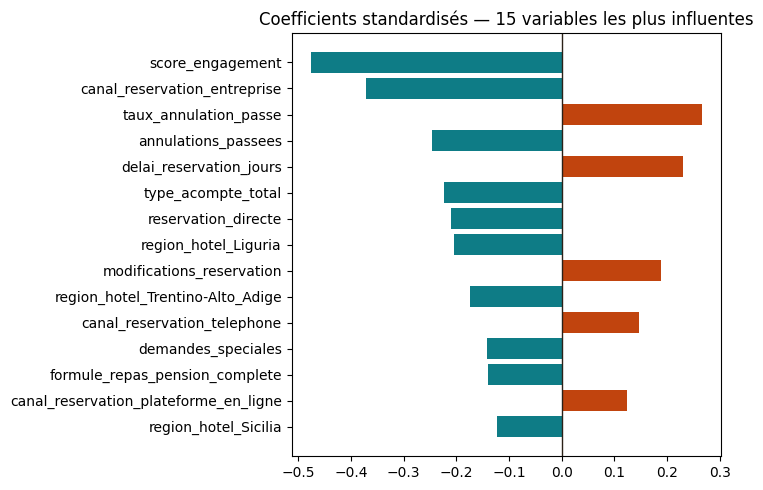

In [20]:
itr, iva = folds[-1]
reference = F.fit_reference(train.iloc[itr])
TR = F.engineer(train.iloc[itr], reference)
VA = F.engineer(train.iloc[iva], reference)

logreg = M.build_logreg()
logreg.fit(TR[colonnes], TR[C.TARGET].values)
coefs = E.coefficients_logreg(logreg, C.MODEL_NUMERIC, C.CATEGORICAL)
print(coefs.head(12).to_string(index=False))

top = coefs.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.barh(top.variable, top.coefficient,
        color=["#C1440E" if c > 0 else "#0E7C86" for c in top.coefficient])
ax.axvline(0, color="#2B2118", lw=1)
ax.set_title("Coefficients standardisés — 15 variables les plus influentes")
plt.tight_layout(); plt.show()

`score_engagement` arrive en tête (coefficient −0,476, odds-ratio 0,62 par
écart-type) : la variable créée à partir du constat d'EDA est bien celle qui
porte le plus d'information. Le canal `entreprise` suit — ces réservations sont
adossées à un déplacement professionnel déjà validé.

### 6.2 Analyse d'erreurs

In [21]:
ensemble_final = M.EnsembleAnnulation(threshold=seuil_final).fit(
    TR[colonnes], TR[C.TARGET].values, reference
)
proba_val = ensemble_final.predict_proba(VA[colonnes])
erreurs = E.error_frame(VA, VA[C.TARGET].values, proba_val, seuil_final)
print(erreurs.type_erreur.value_counts().to_string())

apercu_cols = ["reservation_id", "proba", "delai_reservation_jours", "type_acompte",
               "tarif_remboursable", "canal_reservation", "segment_client",
               "montant_total_eur"]
print()
print("5 faux positifs les plus confiants :")
print(erreurs[erreurs.type_erreur == "faux positif"]
      .nlargest(5, "proba")[apercu_cols].to_string(index=False))
print()
print("5 faux négatifs les plus confiants :")
print(erreurs[erreurs.type_erreur == "faux négatif"]
      .nsmallest(5, "proba")[apercu_cols].to_string(index=False))

type_erreur
vrai négatif    455
faux positif    428
vrai positif    230
faux négatif     87

5 faux positifs les plus confiants :
reservation_id    proba  delai_reservation_jours type_acompte tarif_remboursable   canal_reservation segment_client  montant_total_eur
       R001349 0.679626                      429        aucun                oui          entreprise         groupe            3996.32
       R000207 0.628418                      243        aucun                oui plateforme_en_ligne           solo             912.29
       R009568 0.612226                      120        aucun                oui              agence         groupe            2965.40
       R000051 0.606263                      402      partiel                oui plateforme_en_ligne        famille             517.56
       R005920 0.597019                       25        aucun                oui          site_hotel         groupe            1676.95

5 faux négatifs les plus confiants :
reservation_id    prob

Les deux tableaux sont d'une symétrie frappante : **tous les faux
positifs cumulent aucun acompte + tarif remboursable, tous les faux négatifs
ont versé un acompte total.** Le modèle ne se trompe pas au hasard — il
applique correctement la règle dominante et se fait piéger par les exceptions.

Interprétation : le modèle mesure une **opportunité** d'annuler, pas une
**intention**. L'absence d'acompte rend l'annulation facile, elle ne la rend
pas souhaitée. Symétriquement, annuler après un acompte total non remboursable
suppose une cause exogène (maladie, imprévu professionnel) qu'aucune variable
du dataset ne contient.

### 6.3 Équité : le modèle est-il homogène selon les régions ?

In [22]:
par_region = E.performance_par_groupe(erreurs, "region_hotel")
print(par_region.to_string(index=False))
print()
print("corrélation entre taux d'annulation réel et F1 par région : "
      f"{par_region.taux_annulation_reel.corr(par_region.f1):.2f}")

       region_hotel  effectif  taux_annulation_reel    f1  precision  rappel
Trentino-Alto_Adige       111                 0.315 0.547      0.408   0.829
            Sicilia        88                 0.364 0.545      0.429   0.750
          Lombardia       164                 0.268 0.504      0.386   0.727
              Lazio       187                 0.235 0.483      0.343   0.818
           Campania       131                 0.252 0.473      0.338   0.788
             Puglia        73                 0.219 0.462      0.333   0.750
             Veneto       161                 0.242 0.439      0.321   0.692
            Liguria        99                 0.283 0.416      0.327   0.571
            Toscana       130                 0.223 0.340      0.246   0.552

corrélation entre taux d'annulation réel et F1 par région : 0.67


L'écart va de 0,34 à 0,55, mais la corrélation avec le taux d'annulation
réel est élevée : **le F1 croît mécaniquement avec la prévalence**, à qualité
de classement égale. Attribuer cet écart au modèle serait une erreur
d'interprétation.

Limite majeure : les effectifs vont de 73 à 187 réservations, dont 16 à 47
annulations réelles. L'intervalle de confiance à 95 % sur un F1 estimé sur 16
positifs dépasse ±0,15 — **la moitié des écarts observés est indiscernable du
bruit**.

### 6.4 Calibration et usage opérationnel

Le sujet demande une *probabilité* d'annulation. Encore faut-il qu'elle en soit
une. On vérifie que 25 % annoncés correspondent bien à 25 % observés.

In [23]:
tranches_proba = pd.cut(oof_ensemble.proba, [0, .1, .2, .3, .4, .5, .6, 1.0])
calibration = (oof_ensemble.groupby(tranches_proba, observed=True)
               .agg(n=("y", "size"), proba_moyenne=("proba", "mean"),
                    taux_reel=("y", "mean")).round(3))
print(calibration.to_string())
print()
print(f"score de Brier : {metriques_finales['brier']:.4f}")

deciles = oof_ensemble.assign(decile=pd.qcut(oof_ensemble.proba, 10, labels=False) + 1)
table_deciles = deciles.groupby("decile").agg(
    n=("y", "size"), proba_moyenne=("proba", "mean"), taux_reel=("y", "mean"))
table_deciles["lift"] = (table_deciles.taux_reel / oof_ensemble.y.mean()).round(2)
table_deciles["part_annulations"] = (
    deciles.groupby("decile").y.sum() / oof_ensemble.y.sum()).round(3)
print()
print(table_deciles.round(3).to_string())

               n  proba_moyenne  taux_reel
proba                                     
(0.0, 0.1]   558          0.079      0.073
(0.1, 0.2]  1228          0.149      0.160
(0.2, 0.3]  1221          0.252      0.256
(0.3, 0.4]  1038          0.345      0.352
(0.4, 0.5]   559          0.440      0.394
(0.5, 0.6]   137          0.543      0.409
(0.6, 1.0]    59          0.662      0.644

score de Brier : 0.1777

          n  proba_moyenne  taux_reel  lift  part_annulations
decile                                                       
1       480          0.076      0.071  0.28             0.028
2       480          0.114      0.125  0.49             0.049
3       480          0.151      0.167  0.65             0.065
4       480          0.191      0.179  0.70             0.070
5       480          0.232      0.246  0.96             0.096
6       480          0.272      0.277  1.08             0.108
7       480          0.309      0.300  1.17             0.117
8       480          0.351   

In [24]:
for borne_basse, borne_haute, niveau in [(0, .20, "vert"), (.20, .40, "orange"),
                                          (.40, 1.01, "rouge")]:
    masque = (oof_ensemble.proba >= borne_basse) & (oof_ensemble.proba < borne_haute)
    print(f"{niveau:7s} [{borne_basse:.2f} ; {borne_haute:.2f}[  "
          f"volume={masque.mean():.1%}  "
          f"taux réel={oof_ensemble.y[masque].mean():.1%}  "
          f"part des annulations captées={oof_ensemble.y[masque].sum() / oof_ensemble.y.sum():.1%}")

vert    [0.00 ; 0.20[  volume=37.2%  taux réel=13.3%  part des annulations captées=19.3%
orange  [0.20 ; 0.40[  volume=47.1%  taux réel=30.0%  part des annulations captées=55.2%
rouge   [0.40 ; 1.01[  volume=15.7%  taux réel=41.6%  part des annulations captées=25.5%


**Recommandation opérationnelle.** Les probabilités étant calibrées, on
propose un dispositif à trois niveaux plutôt qu'une décision binaire : rien sur
le vert, e-mail d'engagement à J−14 sur l'orange, appel du service réservation
avec offre d'arbitrage sur le rouge. Le rouge ne représente que 16 % du volume
— dispositif tenable pour les équipes, là où le seuil unique à 0,240 alerterait
sur 53 % du portefeuille.

**Jamais d'annulation automatique** : à 35 % de précision, le modèle se trompe
deux fois sur trois quand il alerte. Le bon usage des probabilités est
**agrégé** (prévision du taux d'occupation par date d'arrivée), pas
individuel.

---
## 7. Étape 6 du sujet — génération de `submission.csv`

Le modèle final est réentraîné sur **l'intégralité** du train, avec des
références de feature engineering recalculées sur cet ensemble complet. Le
seuil, lui, reste celui déterminé hors-échantillon en 5.2 : il n'est pas
réoptimisé sur des données que le modèle a vues.

In [25]:
reference_complete = F.fit_reference(train)
TRAIN = F.engineer(train, reference_complete)
TEST = F.engineer(test, reference_complete)

modele_final = M.EnsembleAnnulation(threshold=seuil_final).fit(
    TRAIN[colonnes], train[C.TARGET].values, reference_complete
)
proba_test = modele_final.predict_proba(TEST[colonnes])
decision_test = (proba_test >= seuil_final).astype(int)

submission = pd.DataFrame({
    "reservation_id": test["reservation_id"],
    "probabilite_annulation": np.round(proba_test, 6),
    "reservation_annulee": decision_test,
})
submission.to_csv(C.SUBMISSION_PATH, index=False)

print(f"lignes : {len(submission)}")
print(f"taux d'alerte : {decision_test.mean():.4f}")
print(f"probabilité moyenne : {proba_test.mean():.4f} "
      f"(taux d'annulation du train : {train[C.TARGET].mean():.4f})")
submission.head()

lignes : 2000
taux d'alerte : 0.4900
probabilité moyenne : 0.2449 (taux d'annulation du train : 0.2584)


,reservation_id,probabilite_annulation,reservation_annulee
0,R002267,0.190331,0
1,R002852,0.124397,0
2,R003752,0.372779,1
3,R009926,0.308182,1
4,R000141,0.287190,1


### Vérifications de conformité

Les cinq exigences du sujet sont contrôlées par des assertions : si l'une
échoue, le notebook s'arrête plutôt que de produire un fichier invalide.

In [26]:
modele_reference = pd.read_csv(C.DATA_DIR / "sample_submission.csv")

assert len(submission) == 2000, "submission.csv doit contenir 2 000 lignes"
assert list(submission.columns) == [
    "reservation_id", "probabilite_annulation", "reservation_annulee"
], "colonnes non conformes"
assert (submission.reservation_id.values
        == modele_reference.reservation_id.values).all(), \
    "l'ordre des identifiants doit être celui du fichier de test"
assert submission.probabilite_annulation.between(0, 1).all(), "probabilités hors [0, 1]"
assert submission.reservation_annulee.isin([0, 1]).all(), "décisions non binaires"

print("Les cinq vérifications de conformité sont passées.")

Les cinq vérifications de conformité sont passées.


---
## 8. Synthèse

| Indicateur | Valeur |
|---|---:|
| F1 hors-échantillon (modèle final) | **0,4744** |
| F1 de la baseline imposée | 0,4693 |
| F1 de la stratégie triviale « tout annulé » | 0,4077 |
| ROC-AUC | 0,673 |
| Score de Brier | 0,178 |
| Seuil retenu | 0,240 |

**Ce que nous avons trouvé.** Le risque d'annulation est multiplicatif :
l'engagement financier module l'effet du délai. La variable qui condense ce
constat, `score_engagement`, devient le premier coefficient du modèle.

**Ce que nous n'avons pas trouvé.** Un modèle performant. L'AUC plafonne à 0,67
quelles que soient la famille et la configuration de variables. Les données
décrivent la *structure commerciale* d'une réservation mais pas le
*comportement* du client : c'est cette information manquante qui borne
mécaniquement la performance, et aucun réglage d'hyperparamètre n'y changera
quoi que ce soit.

**Ce que nous en tirons.** Dans un problème où toutes les approches convergent,
l'effort marginal est mieux investi dans la calibration, la rigueur du
protocole et la traduction opérationnelle que dans la course au dixième de
point de F1. Le prochain gain significatif viendra de nouvelles données —
signaux d'interaction client, contexte externe, horodatage des modifications —
et non d'un meilleur modèle.

*Rapport complet et réponses détaillées : `README.md`.*